In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
file_path = "/content/drive/MyDrive/Thesis/DataSet/plot_data.geojson"

gdf = gpd.read_file(file_path)

print(gdf.head())
print(f"Total Polygons: {len(gdf)}")
print(f"Coordinate Reference System (CRS): {gdf.crs}")

gdf.plot(edgecolor='black', alpha=0.5)
plt.show()

In [ ]:
gdf

,height,stock_per_ha,prevailing_species,age,basal_area,carbon_content,pred_prevailing_species,pred_age,pred_basal_area,pred_carbon_content,...,set_size_age,reg_unc_basal_area,reg_unc_carbon_content,reg_unc_height,reg_unc_stock_per_ha,delta_basal_area,delta_carbon_content,delta_height,delta_stock_per_ha,geometry
0,4.0,10,2,1,2.500000,3.2853,2,2,7.506804,20.065426,...,3,2.386765,7.716141,2.915815,35.782429,5.006804,16.780126,5.319592,89.763992,"POLYGON ((15981220.197 5851735.97, 15981221.37..."
1,15.0,210,1,0,14.000000,48.4050,1,2,9.294976,39.367012,...,3,3.596260,10.339084,1.944664,78.118866,4.705024,9.037988,0.080104,53.135086,"POLYGON ((15974799.199 5831590.903, 15974855.1..."
2,16.0,120,2,2,7.500000,35.9268,2,2,8.402432,37.740921,...,1,1.787455,10.771839,1.856159,51.461235,0.902431,1.814121,0.214013,26.110916,"POLYGON ((15811967.813 5988065.035, 15811972.7..."
3,19.0,230,3,2,12.105263,65.4350,1,2,10.064264,39.604771,...,1,2.966490,13.734866,2.935303,40.885674,2.040999,25.830229,5.969537,94.164536,"POLYGON ((15906573.942 5883539.53, 15906565.73..."
4,16.0,100,2,2,6.250000,29.9390,2,2,7.335102,37.867325,...,1,2.411505,6.534421,3.533847,43.850113,1.085102,7.928325,0.061390,5.441765,"POLYGON ((15826293.328 5976423.531, 15826418.8..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35360,17.0,140,2,2,8.235294,41.9146,2,2,8.537437,39.817806,...,2,2.395665,10.152507,2.328644,34.706520,0.302143,2.096794,0.435301,9.733093,"POLYGON ((15804242.863 5795948.36, 15804256.04..."
35361,14.0,80,2,2,5.714286,23.9512,2,2,7.707396,24.081499,...,1,3.091096,6.823709,1.970565,38.210968,1.993110,0.130299,0.595816,5.211731,"POLYGON ((15822481.395 5937669.238, 15822600.6..."
35362,12.0,50,2,2,4.166667,14.9695,2,2,4.934263,22.875734,...,1,1.733565,7.340171,2.816599,61.605675,0.767596,7.906234,0.218600,44.897690,"POLYGON ((15974919.943 5849891.688, 15974921.5..."
35363,16.0,100,2,2,6.250000,29.9390,2,2,8.544954,30.248798,...,1,2.092934,10.032210,2.734856,57.228653,2.294954,0.309798,0.542833,65.103836,"POLYGON ((15917306.243 5944434.373, 15917276.6..."


In [ ]:
gdf.columns

Index(['height', 'stock_per_ha', 'prevailing_species', 'age', 'basal_area',
       'carbon_content', 'pred_prevailing_species', 'pred_age',
       'pred_basal_area', 'pred_carbon_content', 'pred_height',
       'pred_stock_per_ha', 'set_size_prevailing_species', 'set_size_age',
       'reg_unc_basal_area', 'reg_unc_carbon_content', 'reg_unc_height',
       'reg_unc_stock_per_ha', 'delta_basal_area', 'delta_carbon_content',
       'delta_height', 'delta_stock_per_ha', 'geometry'],
      dtype='object')

Pipeline

In [ ]:
import geopandas as gpd
import os

def prepare_master_file(input_geojson, output_gpkg, target_crs="EPSG:32654"):
    print(f"Reading Input: {input_geojson}")

    gdf = gpd.read_file(input_geojson)
    print(f"Original CRS: {gdf.crs}")
    print(f"Original Row Count: {len(gdf)}")

    # Reproject to match Satellite Images (EPSG:32654)
    if gdf.crs != target_crs:
        print(f"Reprojecting to {target_crs}...")
        gdf = gdf.to_crs(target_crs)
    else:
        print(f"Already in {target_crs}. Skipping reprojection.")

    # Add Unique ID
    gdf['poly_id'] = gdf.index
    print("Added 'poly_id' column.")

    # Save to GeoPackage
    gdf.to_file(output_gpkg, driver="GPKG")
    print("-" * 30)
    print(f"SUCCESS! Saved Master Training File to:\n{output_gpkg}")
    print("-" * 30)

INPUT_FILE = "/content/plot_data.geojson"

OUTPUT_FILE = "/content/drive/MyDrive/Thesis/DataSet/Training_Master.gpkg"
prepare_master_file(INPUT_FILE, OUTPUT_FILE)

Reading Input: /content/plot_data.geojson
Original CRS: EPSG:3857
Original Row Count: 35365
Reprojecting to EPSG:32654...
Added 'poly_id' column.
------------------------------
SUCCESS! Saved Master Training File to:
/content/drive/MyDrive/Thesis/DataSet/Training_Master.gpkg
------------------------------


In [ ]:
import rasterio
from rasterstats import zonal_stats
from rasterio import Affine
import geopandas as gpd
import pandas as pd
import numpy as np
import glob
import os
from shapely.geometry import box
import re

def extract_stats_for_folder(image_folder, master_gdf, prefix):
    """
    Extracts stats for a specific folder (S2 or AEF) and returns a DataFrame.
    Prefix: 'S2' or 'AEF'
    """
    tif_files = glob.glob(os.path.join(image_folder, "*.tif"))
    if not tif_files:
        print(f"WARNING: No .tif files found in {image_folder}")
        return pd.DataFrame()

    print(f"--- Processing {prefix} ({len(tif_files)} tiles) ---")
    all_rows = []

    for idx, tiff_path in enumerate(tif_files):
        filename = os.path.basename(tiff_path)
        try:
            with rasterio.open(tiff_path) as src:
                # SPATIAL FILTER: Only polygons touching this image
                bounds = src.bounds
                geom = box(bounds.left, bounds.bottom, bounds.right, bounds.top)
                subset_gdf = master_gdf[master_gdf.intersects(geom)].copy()

                if subset_gdf.empty:
                    continue # Skip if no polygons here

                # Get Date or Year
                time_val = "Unknown"
                if prefix == "S2":
                    # Matches YYYY-MM-DD
                    match = re.search(r'\d{4}-\d{2}-\d{2}', filename)
                    if match: time_val = match.group()
                elif prefix == "AEF":
                    # Matches YYYY
                    match = re.search(r'\d{4}', filename)
                    if match: time_val = match.group()

                # AEF FIX: Check for Positive Y-Scale (Bottom-Up)
                is_bottom_up = src.transform.e > 0
                if is_bottom_up:
                    working_transform = Affine(
                        src.transform.a, src.transform.b, src.transform.c,
                        src.transform.d, -src.transform.e, src.transform.f + (src.height * src.transform.e)
                    )
                else:
                    working_transform = src.transform

                # STATS LOOP (Band by Band)
                num_bands = src.count

                # Dictionary to store stats for this subset of polygons
                # key = poly_id, value = dict of stats
                poly_stats_map = {pid: {'poly_id': pid, f'{prefix}_Date': time_val} for pid in subset_gdf['poly_id']}

                for b in range(1, num_bands + 1):
                    band_data = src.read(b)
                    if is_bottom_up:
                        band_data = np.flipud(band_data)

                    # Calculate stats (mean, std, min, max)
                    stats = zonal_stats(
                        subset_gdf, band_data, affine=working_transform,
                        stats=['mean', 'std', 'min', 'max'], nodata=np.nan
                    )

                    # Add to dictionary
                    col_base = f"{prefix}_B{b}"
                    for i, s in enumerate(stats):
                        pid = subset_gdf.iloc[i]['poly_id']
                        if s['mean'] is not None:
                            poly_stats_map[pid][f"{col_base}_mean"] = s['mean']
                            poly_stats_map[pid][f"{col_base}_std"] = s['std']
                            poly_stats_map[pid][f"{col_base}_min"] = s['min']
                            poly_stats_map[pid][f"{col_base}_max"] = s['max']

                # Convert dict values to list of rows
                all_rows.extend(list(poly_stats_map.values()))
                print(f"   [{idx+1}/{len(tif_files)}] {filename}: Extracted {len(subset_gdf)} polygons.")

        except Exception as e:
            print(f"   Error processing {filename}: {e}")
            continue

    if all_rows:
        return pd.DataFrame(all_rows)
    else:
        return pd.DataFrame()

def generate_combined_csv(s2_folder, aef_folder, master_gpkg, output_csv):

    # Load Master Polygons
    print(f"Loading Master File: {os.path.basename(master_gpkg)}")
    master_gdf = gpd.read_file(master_gpkg)
    print(f"Total Polygons: {len(master_gdf)}")

    # Extract S2 Stats
    print("\n--- Starting Sentinel-2 Extraction ---")
    s2_df = extract_stats_for_folder(s2_folder, master_gdf, prefix="S2")

    # Extract AEF Stats
    print("\n--- Starting Alpha Earth Extraction ---")
    aef_df = extract_stats_for_folder(aef_folder, master_gdf, prefix="AEF")

    # Merge
    print("\n--- Merging Data ---")
    # Start with all master poly_ids to ensure we don't lose shapes
    final_df = pd.DataFrame({'poly_id': master_gdf['poly_id']})

    if not s2_df.empty:
        # We drop duplicates just in case multiple tiles covered the same polygon
        s2_df = s2_df.drop_duplicates(subset=['poly_id'])
        final_df = final_df.merge(s2_df, on='poly_id', how='left')
    else:
        print("Warning: S2 DataFrame is empty.")

    if not aef_df.empty:
        aef_df = aef_df.drop_duplicates(subset=['poly_id'])
        final_df = final_df.merge(aef_df, on='poly_id', how='left')
    else:
        print("Warning: AEF DataFrame is empty.")

    # Clean and Save
    # Remove rows that have NO data (optional, but good for cleanliness)
    final_df = final_df.dropna(subset=[col for col in final_df.columns if 'mean' in col], how='all')

    print(f"Saving final CSV with {len(final_df)} rows and {len(final_df.columns)} columns...")
    final_df.to_csv(output_csv, index=False)
    print(f"SUCCESS! Saved to: {output_csv}")

PATH_S2_DAY = "/content/drive/MyDrive/Sentinel-2_Sakhalin/S2_KSK_2019-07-22"
PATH_AEF_YEAR = "/content/drive/MyDrive/Final_Embeddings/EE_Embeddings_KSK/AEF_KSK_2019"
PATH_GPKG = "/content/drive/MyDrive/Thesis/DataSet/Training_Master.gpkg"
OUTPUT_CSV = "/content/drive/MyDrive/Thesis/DataSet/Final_csv_files_for_each_day/Forest_KSK_2019_07_22_Stats_2.csv"

generate_combined_csv(PATH_S2_DAY, PATH_AEF_YEAR, PATH_GPKG, OUTPUT_CSV)

Loading Master File: Training_Master.gpkg
Total Polygons: 35365

--- Starting Sentinel-2 Extraction ---
--- Processing S2 (1 tiles) ---
   [1/1] NewS2_KSK_2019-07-22-0000006656-0000000000.tif: Extracted 6147 polygons.

--- Starting Alpha Earth Extraction ---
--- Processing AEF (17 tiles) ---
   [1/17] embedding_KSK2019-0000000000-0000003072.tif: Extracted 1226 polygons.
   [3/17] embedding_KSK2019-0000003072-0000003072.tif: Extracted 3280 polygons.
   [4/17] embedding_KSK2019-0000003072-0000006144.tif: Extracted 368 polygons.
   [5/17] embedding_KSK2019-0000006144-0000003072.tif: Extracted 5283 polygons.
   [7/17] embedding_KSK2019-0000009216-0000003072.tif: Extracted 17 polygons.
   [9/17] embedding_KSK2019-0000006144-0000000000.tif: Extracted 5597 polygons.
   [10/17] embedding_KSK2019-0000009216-0000000000.tif: Extracted 2905 polygons.
   [11/17] embedding_KSK2019-0000012288-0000000000.tif: Extracted 112 polygons.

--- Merging Data ---
Saving final CSV with 18443 rows and 331 column

In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Thesis/DataSet/Final_csv_files_for_each_day/Forest_KSK_2019_07_22_Stats_2.csv")

In [ ]:
df

,poly_id,S2_Date,S2_B1_mean,S2_B1_std,S2_B1_min,S2_B1_max,S2_B2_mean,S2_B2_std,S2_B2_min,S2_B2_max,...,AEF_B62_min,AEF_B62_max,AEF_B63_mean,AEF_B63_std,AEF_B63_min,AEF_B63_max,AEF_B64_mean,AEF_B64_std,AEF_B64_min,AEF_B64_max
0,0,2019-07-22,0.030238,0.006461,0.0210,0.0370,0.038768,0.004061,0.0316,0.0491,...,-0.079723,0.010396,-0.126802,0.039111,-0.186082,-0.035433,-0.006574,0.031886,-0.066990,0.062991
1,1,2019-07-22,0.033956,0.017644,0.0163,0.0815,0.041241,0.024456,0.0172,0.1552,...,-0.044844,0.141730,0.075056,0.047546,-0.079723,0.192910,0.172725,0.053638,-0.013841,0.251965
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.059116,0.066990,-0.045292,0.038657,-0.130165,0.062991,0.072224,0.049093,-0.055363,0.160000
3,5,2019-07-22,0.023720,0.001043,0.0220,0.0266,0.028554,0.001978,0.0232,0.0389,...,0.027128,0.088827,0.038598,0.034050,-0.075356,0.141730,0.135083,0.025890,0.062991,0.221453
4,7,2019-07-22,0.022652,0.002125,0.0209,0.0287,0.025984,0.004538,0.0208,0.0501,...,0.006151,0.103406,0.015270,0.033627,-0.071111,0.098424,0.090699,0.019792,0.027128,0.141730
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18438,35353,2019-07-22,0.017985,0.001358,0.0166,0.0200,0.027876,0.004753,0.0201,0.0369,...,-0.098424,0.062991,-0.232392,0.047149,-0.327812,-0.141730,-0.018568,0.038630,-0.071111,0.079723
18439,35356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.041584,0.022207,0.016863,0.027070,-0.048228,0.088827,0.072664,0.034282,-0.004983,0.186082
18440,35359,2019-07-22,0.274207,0.066897,0.1287,0.4300,0.287394,0.088315,0.0880,0.5380,...,-0.066990,0.062991,-0.122424,0.051989,-0.259900,0.003937,-0.017743,0.071640,-0.098424,0.186082
18441,35362,2019-07-22,0.016771,0.000795,0.0157,0.0188,0.023580,0.002073,0.0164,0.0328,...,-0.075356,0.147697,-0.036117,0.037714,-0.147697,0.079723,0.051936,0.043621,-0.035433,0.172795


###Checking the polygons

In [ ]:
import pandas as pd
import geopandas as gpd
import os

def create_verification_gpkg(csv_path, master_gpkg_path, output_gpkg_path):
    print("1. Loading CSV (Stats)...")
    df = pd.read_csv(csv_path)
    print(f"   -> CSV Rows: {len(df)}")

    # Ensure poly_id is integer for matching
    df['poly_id'] = df['poly_id'].astype(int)

    print("2. Loading Master Polygons...")
    gdf = gpd.read_file(master_gpkg_path)
    print(f"   -> Master Polygons: {len(gdf)}")

    # Ensure poly_id is integer
    gdf['poly_id'] = gdf['poly_id'].astype(int)

    print("3. Merging Data...")
    # 'inner': Keep only polygons that appear in your CSV
    # This effectively filters the Master file to show ONLY what you extracted
    merged_gdf = gdf.merge(df, on='poly_id', how='inner')

    print(f"   -> Matched Polygons: {len(merged_gdf)}")

    if len(merged_gdf) == 0:
        print("ERROR: No IDs matched! Check if 'poly_id' columns are correct.")
        return

    print(f"4. Saving to {output_gpkg_path}...")
    merged_gdf.to_file(output_gpkg_path, driver="GPKG")
    print("SUCCESS! File is ready for QGIS.")

# --- USER INPUT ---
# 1. Your newly generated CSV
csv_file = "/content/drive/MyDrive/Thesis/DataSet/Final_csv_files_for_each_day/Forest_KSK_2019_07_22_Stats.csv"

# 2. Your Training Master GPKG
master_file = "/content/drive/MyDrive/Thesis/DataSet/Training_Master.gpkg"

# 3. Output Check File
output_file = "/content/drive/MyDrive/Thesis/DataSet/CHECK_RESULT.gpkg"

create_verification_gpkg(csv_file, master_file, output_file)

1. Loading CSV (Stats)...
   -> CSV Rows: 18509
2. Loading Master Polygons...
   -> Master Polygons: 35365
3. Merging Data...
   -> Matched Polygons: 18509
4. Saving to /content/drive/MyDrive/Thesis/DataSet/CHECK_RESULT.gpkg...
SUCCESS! File is ready for QGIS.


###Checking aef folder

In [ ]:
import rasterio
import geopandas as gpd
from shapely.geometry import box
import glob
import os

def diagnose_folder(image_folder, master_gpkg):
    # 1. Load Master Polygons
    print("Loading Master Polygons...")
    master_gdf = gpd.read_file(master_gpkg)
    # Ensure they are in the same CRS as the images usually are (32654)
    if master_gdf.crs != "EPSG:32654":
        master_gdf = master_gdf.to_crs("EPSG:32654")

    print(f"Loaded {len(master_gdf)} polygons.")

    # 2. Get All Files
    tif_files = glob.glob(os.path.join(image_folder, "*.tif"))
    print(f"Found {len(tif_files)} TIF files in folder.")
    print("-" * 50)

    # 3. Check Each File
    for idx, tiff_path in enumerate(tif_files):
        filename = os.path.basename(tiff_path)

        try:
            with rasterio.open(tiff_path) as src:
                # Create Bounding Box of the Image
                bounds = src.bounds
                geom = box(bounds.left, bounds.bottom, bounds.right, bounds.top)

                # Check Intersection
                subset_gdf = master_gdf[master_gdf.intersects(geom)]

                status = "✅ KEEP" if not subset_gdf.empty else "❌ SKIP"
                count = len(subset_gdf)

                print(f"[{idx+1}] {filename}")
                print(f"    -> Status: {status}")
                print(f"    -> Polygons inside: {count}")
                if count == 0:
                    print(f"    -> Reason: Master polygons do not overlap this image area.")

        except Exception as e:
            print(f"[{idx+1}] {filename} -> ERROR: {e}")

        print("-" * 20)

# --- USER INPUT ---
FOLDER = "/content/drive/MyDrive/Final_Embeddings/EE_Embeddings_KSK/AEF_KSK_2019"
MASTER = "/content/drive/MyDrive/Thesis/DataSet/Training_Master.gpkg"

diagnose_folder(FOLDER, MASTER)

Loading Master Polygons...
Loaded 35365 polygons.
Found 17 TIF files in folder.
--------------------------------------------------
[1] embedding_KSK2019-0000000000-0000003072.tif
    -> Status: ✅ KEEP
    -> Polygons inside: 1226
--------------------
[2] embedding_KSK2019-0000000000-0000006144.tif
    -> Status: ❌ SKIP
    -> Polygons inside: 0
    -> Reason: Master polygons do not overlap this image area.
--------------------
[3] embedding_KSK2019-0000003072-0000003072.tif
    -> Status: ✅ KEEP
    -> Polygons inside: 3280
--------------------
[4] embedding_KSK2019-0000003072-0000006144.tif
    -> Status: ✅ KEEP
    -> Polygons inside: 368
--------------------
[5] embedding_KSK2019-0000006144-0000003072.tif
    -> Status: ✅ KEEP
    -> Polygons inside: 5283
--------------------
[6] embedding_KSK2019-0000006144-0000006144.tif
    -> Status: ❌ SKIP
    -> Polygons inside: 0
    -> Reason: Master polygons do not overlap this image area.
--------------------
[7] embedding_KSK2019-00000092

###Extraction for KSK

In [ ]:
import rasterio
from rasterstats import zonal_stats
from rasterio import Affine
import geopandas as gpd
import pandas as pd
import numpy as np
import glob
import os
from shapely.geometry import box
import re

def extract_stats_smart(image_folder, master_gpkg, output_csv, sensor_type="AEF"):

    # 1. Load Master Polygons (Keep original)
    print(f"Loading Master Polygons from: {os.path.basename(master_gpkg)}")
    master_gdf_orig = gpd.read_file(master_gpkg)
    print(f"   Total Polygons: {len(master_gdf_orig)}")
    print(f"   Master CRS: {master_gdf_orig.crs}")

    # 2. Find Images
    tif_files = glob.glob(os.path.join(image_folder, "*.tif"))
    if not tif_files:
        print(f"ERROR: No .tif files found in {image_folder}")
        return

    print(f"--- Processing {len(tif_files)} images for {sensor_type} ---")
    all_results = []

    for idx, tiff_path in enumerate(tif_files):
        filename = os.path.basename(tiff_path)
        print(f"[{idx+1}/{len(tif_files)}] Processing {filename}...")

        try:
            with rasterio.open(tiff_path) as src:
                # --- SMART CRS HANDLING ---
                # Check if Image CRS matches Master CRS
                image_crs = src.crs

                if image_crs is None:
                    print("   -> SKIP: Image has no CRS defined.")
                    continue

                # Prepare polygons for THIS SPECIFIC image
                if master_gdf_orig.crs != image_crs:
                    # Reproject polygons to match the image (Fast & RAM efficient)
                    # print(f"   -> Reprojecting polygons to match image ({image_crs})...")
                    working_gdf = master_gdf_orig.to_crs(image_crs)
                else:
                    working_gdf = master_gdf_orig

                # --- SPATIAL FILTER ---
                # Now that CRSs match, we can check intersection safely
                bounds = src.bounds
                geom = box(bounds.left, bounds.bottom, bounds.right, bounds.top)

                subset_gdf = working_gdf[working_gdf.intersects(geom)].copy()

                if subset_gdf.empty:
                    print(f"   -> Skipped (Truly empty area)")
                    continue

                # --- METADATA (Date/Year) ---
                time_val = "Unknown"
                if sensor_type == "S2":
                    match = re.search(r'\d{4}-\d{2}-\d{2}', filename)
                    if match: time_val = match.group()
                elif sensor_type == "AEF":
                    match = re.search(r'\d{4}', filename)
                    if match: time_val = match.group()

                # --- AEF FIX (Bottom-Up) ---
                is_bottom_up = src.transform.e > 0
                if is_bottom_up:
                    working_transform = Affine(
                        src.transform.a, src.transform.b, src.transform.c,
                        src.transform.d, -src.transform.e, src.transform.f + (src.height * src.transform.e)
                    )
                else:
                    working_transform = src.transform

                # --- EXTRACT STATS ---
                num_bands = src.count
                # Pre-fill dictionary
                poly_stats_map = {pid: {'poly_id': pid, f'{sensor_type}_Date': time_val} for pid in subset_gdf['poly_id']}

                for b in range(1, num_bands + 1):
                    band_data = src.read(b)
                    if is_bottom_up:
                        band_data = np.flipud(band_data)

                    stats = zonal_stats(
                        subset_gdf, band_data, affine=working_transform,
                        stats=['mean', 'std'], nodata=np.nan
                    )

                    col_base = f"{sensor_type}_B{b}"
                    for i, s in enumerate(stats):
                        pid = subset_gdf.iloc[i]['poly_id']
                        if s['mean'] is not None:
                            poly_stats_map[pid][f"{col_base}_mean"] = s['mean']
                            poly_stats_map[pid][f"{col_base}_std"] = s['std']

                all_results.extend(list(poly_stats_map.values()))
                print(f"   -> Success! Extracted {len(subset_gdf)} polygons.")

        except Exception as e:
            print(f"   -> Error: {e}")
            continue

    # 3. Save to CSV
    if all_results:
        print(f"Saving {len(all_results)} rows to {output_csv}...")
        df = pd.DataFrame(all_results)
        df.to_csv(output_csv, index=False)
        print("Success.")
    else:
        print("No data extracted.")

# --- USER CONFIGURATION ---
MASTER_GPKG = "/content/drive/MyDrive/Thesis/DataSet/Training_Master.gpkg"

# 1. Run for AEF (The tricky folder)
extract_stats_smart(
    image_folder="/content/drive/MyDrive/Final_Embeddings/EE_Embeddings_KSK/AEF_KSK_2018",
    master_gpkg=MASTER_GPKG,
    output_csv="/content/drive/MyDrive/Thesis/DataSet/Final_csv_files_for_each_day/Forest_KSK_AEF_2018Stats.csv"
,
    sensor_type="AEF"
)

# 2. Run for S2 (Standard folder)
# extract_stats_smart(
#     image_folder="/content/drive/MyDrive/.../Forest_A/S2_2020...",
#     master_gpkg=MASTER_GPKG,
#     output_csv="/content/drive/MyDrive/.../Forest_A_S2_Smart_Stats.csv",
#     sensor_type="S2"
# )

Loading Master Polygons from: Training_Master.gpkg
   Total Polygons: 35365
   Master CRS: EPSG:32654
--- Processing 17 images for AEF ---
[1/17] Processing embedding_KSK2018-0000000000-0000003072.tif...
   -> Success! Extracted 1226 polygons.
[2/17] Processing embedding_KSK2018-0000000000-0000006144.tif...
   -> Skipped (Truly empty area)
[3/17] Processing embedding_KSK2018-0000003072-0000003072.tif...
   -> Success! Extracted 3280 polygons.
[4/17] Processing embedding_KSK2018-0000003072-0000006144.tif...
   -> Success! Extracted 368 polygons.
[5/17] Processing embedding_KSK2018-0000006144-0000003072.tif...
   -> Success! Extracted 5283 polygons.
[6/17] Processing embedding_KSK2018-0000006144-0000006144.tif...
   -> Skipped (Truly empty area)
[7/17] Processing embedding_KSK2018-0000009216-0000003072.tif...
   -> Success! Extracted 17 polygons.
[8/17] Processing embedding_KSK2018-0000003072-0000000000.tif...
   -> Skipped (Truly empty area)
[9/17] Processing embedding_KSK2018-000000614

In [ ]:
extract_stats_smart(
    image_folder="/content/drive/MyDrive/Final_Embeddings/EE_Embeddings_KSK/AEF_KSK_2018",
    master_gpkg=MASTER_GPKG,
    output_csv="/content/drive/MyDrive/Thesis/DataSet/Final_csv_files_for_each_day/Forest_KSK_AEF_2018Stats.csv",
    sensor_type="AEF"
)

NameError: name 'extract_stats_smart' is not defined

In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Thesis/DataSet/Final_csv_files_for_each_day/Forest_KSK_AEF_2018Stats.csv")

In [ ]:
df

,poly_id,AEF_Date,AEF_B1_mean,AEF_B1_std,AEF_B2_mean,AEF_B2_std,AEF_B3_mean,AEF_B3_std,AEF_B4_mean,AEF_B4_std,...,AEF_B60_mean,AEF_B60_std,AEF_B61_mean,AEF_B61_std,AEF_B62_mean,AEF_B62_std,AEF_B63_mean,AEF_B63_std,AEF_B64_mean,AEF_B64_std
0,43,2018,-0.073700,0.019070,0.070587,0.025614,0.046315,0.036332,-0.057926,0.033940,...,0.071781,0.036366,-0.025003,0.016703,-0.024589,0.037421,-0.074141,0.060753,0.069870,0.053734
1,50,2018,-0.048352,0.039363,0.038276,0.042402,-0.032391,0.044194,-0.023487,0.028585,...,0.042146,0.014844,-0.020458,0.022965,0.009090,0.029625,0.088935,0.065103,0.190053,0.043466
2,91,2018,-0.008456,0.055251,-0.000173,0.050478,0.017401,0.020282,-0.099277,0.017080,...,0.121234,0.022698,0.015842,0.021593,-0.025693,0.041710,-0.068664,0.076579,0.085457,0.036200
3,118,2018,0.017026,0.047518,0.067644,0.033485,0.004505,0.034626,-0.001711,0.040885,...,0.000101,0.034783,-0.039154,0.017699,0.047982,0.027405,-0.005373,0.064334,0.079903,0.050923
4,129,2018,-0.041344,0.020941,0.087012,0.026770,0.038876,0.041398,0.002106,0.027527,...,0.020490,0.030809,-0.037272,0.015421,0.028944,0.033286,-0.064944,0.106934,0.066136,0.078798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29134,35162,2018,-0.001447,0.054538,0.019094,0.025655,0.096339,0.028698,-0.090576,0.023558,...,-0.015459,0.034608,-0.091172,0.022193,-0.008672,0.026141,0.009235,0.051562,0.086219,0.057318
29135,35164,2018,0.069949,0.034320,0.046643,0.017374,0.020464,0.023883,-0.081712,0.037835,...,0.075329,0.017038,-0.007411,0.017946,0.034418,0.038953,-0.103766,0.064995,0.059628,0.061034
29136,35186,2018,-0.022833,0.022125,0.084577,0.011644,0.003376,0.022647,-0.011081,0.026413,...,0.011908,0.023178,-0.034485,0.015895,-0.021230,0.029174,-0.080706,0.046104,0.060697,0.046685
29137,35253,2018,0.040347,0.041749,0.041105,0.023641,-0.031340,0.020681,-0.039269,0.022382,...,0.041290,0.023081,-0.024161,0.012252,-0.022446,0.029678,-0.006906,0.028724,0.047073,0.027580


In [ ]:
df['poly_id'].value_counts()

,count
poly_id,
9829,5
4771,5
17675,4
20041,4
6364,4
...,...
33568,1
32937,1
31387,1


Count : 23 pixels
Min   : 11.0
Max   : 98.0
Mean  : 57.17
Std: 26.0

Mask pixel count: 23  (matches rasterstats: True)


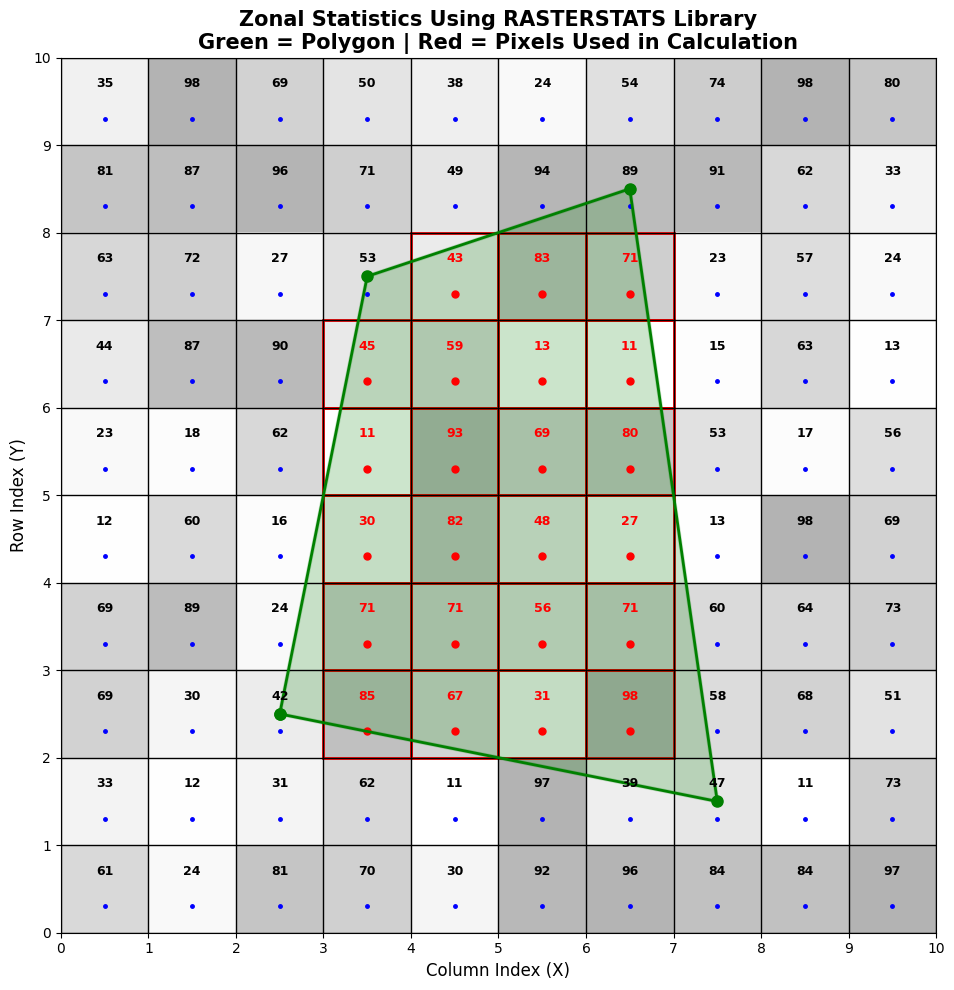

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from shapely.geometry import Polygon
from rasterstats import zonal_stats
from affine import Affine

np.random.seed(42)
rows, cols = 10, 10
data = np.random.randint(10, 99, size=(rows, cols))

polygon_coords = [
    (2.5, 2.5),
    (7.5, 1.5),
    (6.5, 8.5),
    (3.5, 7.5),
    (2.5, 2.5)
]
polygon = Polygon(polygon_coords)
transform = Affine(1.0, 0.0, 0.0, 0.0, -1.0, rows)
data_flipped = np.flipud(data)

# ── Ask rasterstats for its own raster output ────────────────────────────────
stats_list = zonal_stats(
    polygon,
    data_flipped,
    affine=transform,
    stats=['count', 'min', 'max', 'mean', 'std'],
    nodata=-999,
    raster_out=True
)

stats = stats_list[0]
print(f"Count : {stats['count']} pixels")
print(f"Min   : {stats['min']}")
print(f"Max   : {stats['max']}")
print(f"Mean  : {stats['mean']:.2f}")
print(f"Std: {stats['std']:.1f}")

#
mini = stats['mini_raster_array']
mini_transform = stats['mini_raster_affine']


origin_col = int(round(mini_transform.c))
origin_row = int(round(rows - mini_transform.f))

# Build full-grid boolean mask (in data_flipped row order)
mask_flipped = np.zeros((rows, cols), dtype=bool)
mr, mc = mini.shape
for ri in range(mr):
    for ci in range(mc):
        if not mini.mask[ri, ci]:
            gri = origin_row + ri
            gci = origin_col + ci
            if 0 <= gri < rows and 0 <= gci < cols:
                mask_flipped[gri, gci] = True

# Flip back to original data row order for display
mask = np.flipud(mask_flipped)

print(f"\nMask pixel count: {mask.sum()}  (matches rasterstats: {mask.sum() == stats['count']})")

# ── Plotting ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(data, cmap='Greys', origin='lower', extent=[0, cols, 0, rows], alpha=0.3)
ax.set_xticks(np.arange(cols + 1))
ax.set_yticks(np.arange(rows + 1))
ax.grid(which='major', color='black', linestyle='-', linewidth=1)

for r in range(rows):
    for c in range(cols):
        val = data[r, c]
        cx, cy = c + 0.5, r + 0.5
        is_inside = mask[r, c]

        text_color = 'black'
        dot_color  = 'blue'
        dot_marker = '.'

        if is_inside:
            text_color = 'red'
            dot_color  = 'red'
            dot_marker = 'o'
            rect = patches.Rectangle((c, r), 1, 1, linewidth=2,
                                      edgecolor='red', facecolor='none')
            ax.add_patch(rect)

        ax.text(cx, cy + 0.2, str(val), ha='center', va='center',
                color=text_color, fontsize=9, fontweight='bold')
        ax.plot(cx, cy - 0.2, marker=dot_marker, color=dot_color, markersize=5)

poly_patch = patches.Polygon(polygon_coords, closed=True, linewidth=3,
                              edgecolor='green', facecolor='green', alpha=0.2)
ax.add_patch(poly_patch)
px, py = zip(*polygon_coords)
ax.plot(px, py, 'go-', linewidth=2, markersize=8)

ax.set_title("Zonal Statistics Using RASTERSTATS Library\n"
             "Green = Polygon | Red = Pixels Used in Calculation",
             fontsize=15, fontweight='bold')
ax.set_xlabel("Column Index (X)", fontsize=12)
ax.set_ylabel("Row Index (Y)", fontsize=12)
plt.tight_layout()
plt.show()

#Preparation Final Dataset

In [ ]:
import geopandas as gpd
file_path = "/content/drive/MyDrive/Thesis/DataSet/target_data.geojson"
gdf = gpd.read_file(file_path)
gdf

,forestry,structure,land_use,land_use_group,height,diameter,market,fullness,exposition,degree,...,Birch,Larch,Spruce,Fir,Other,Other soft deciduous,Aspen,Oak,entropy,geometry
0,Холмское,0,Пустыри,Непокрытые лесом земли,13.0,18,4,0.0,Ю,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,"POLYGON ((141.97989 47.63634, 141.98065 47.636..."
1,Холмское,0,Склоны крутые,Неиспользуемые земли,0.0,0,0,0.0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,"POLYGON ((141.97989 47.63634, 141.97959 47.635..."
2,Холмское,5С 2БК 1Л 1Е 1П,Культуры лесные,Покрыте лесом земли,11.0,14,3,0.7,З,16,...,2.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.844541,"POLYGON ((141.99147 47.62802, 141.9912 47.6279..."
3,Холмское,0,Пустыри,Непокрытые лесом земли,13.0,18,4,0.0,З,7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,"POLYGON ((141.97739 47.63003, 141.97539 47.628..."
4,Холмское,5С 2БК 1Л 1Е 1П,Культуры лесные,Покрыте лесом земли,11.0,14,3,0.7,СЗ,19,...,2.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.844541,"POLYGON ((141.98956 47.62737, 141.98948 47.627..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81330,Невельское,0,Пустыри,Непокрытые лесом земли,0.0,0,0,0.0,ЮЗ,14,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,"POLYGON ((142.06503 45.91075, 142.06481 45.911..."
81331,Невельское,0,Пустыри,Непокрытые лесом земли,0.0,0,0,0.0,З,8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,"POLYGON ((142.07584 45.90459, 142.07592 45.903..."
81332,Невельское,0,Пустыри,Непокрытые лесом земли,0.0,0,0,0.0,СЗ,15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,"POLYGON ((142.07203 45.91231, 142.07236 45.912..."
81333,Невельское,0,Пустыри,Непокрытые лесом земли,0.0,0,0,0.0,З,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,"POLYGON ((142.06758 45.90859, 142.06758 45.908..."


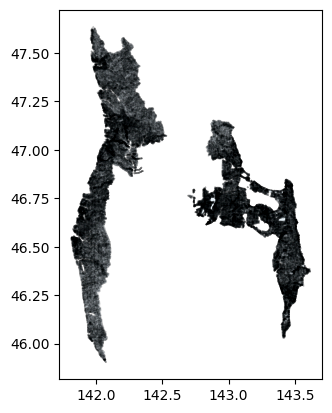

In [ ]:
import matplotlib.pyplot as plt
gdf.plot(edgecolor='Black', alpha=0.1)
plt.show()

##Preparation gpkg file from geojson and reprojection to EPSG 32654

In [ ]:
import geopandas as gpd
import os

def prepare_master_file(input_geojson, output_gpkg, target_crs="EPSG:32654"):
    print(f"Reading Input: {input_geojson}")

    gdf = gpd.read_file(input_geojson)
    print(f"Original CRS: {gdf.crs}")
    print(f"Original Row Count: {len(gdf)}")

    # Reproject to match Satellite Images (EPSG:32654)
    if gdf.crs != target_crs:
        print(f"Reprojecting to {target_crs}...")
        gdf = gdf.to_crs(target_crs)
    else:
        print(f"Already in {target_crs}. Skipping reprojection.")

    # Add Unique ID
    gdf['poly_id'] = gdf.index
    print("Added 'poly_id' column.")

    # Save to GeoPackage
    gdf.to_file(output_gpkg, driver="GPKG")
    print("-" * 30)
    print(f"SUCCESS! Saved Master Training File to:\n{output_gpkg}")
    print("-" * 30)

INPUT_FILE = "/content/drive/MyDrive/Thesis/DataSet/target_data.geojson"

OUTPUT_FILE = "/content/drive/MyDrive/Thesis/DataSet/Polygons.gpkg"
prepare_master_file(INPUT_FILE, OUTPUT_FILE)

Reading Input: /content/drive/MyDrive/Thesis/DataSet/target_data.geojson
Original CRS: EPSG:4326
Original Row Count: 81335
Reprojecting to EPSG:32654...
Added 'poly_id' column.
------------------------------
SUCCESS! Saved Master Training File to:
/content/drive/MyDrive/Thesis/DataSet/Polygons.gpkg
------------------------------


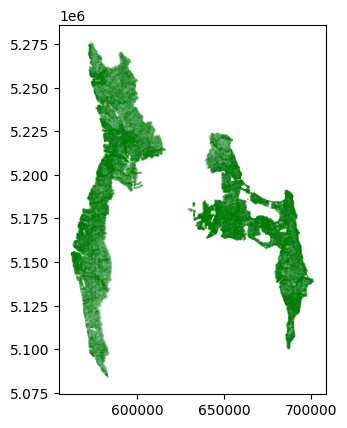

In [ ]:
gdfnew = gpd.read_file(OUTPUT_FILE)
gdfnew.plot(edgecolor="Green", alpha = 0.1)
plt.show()

##CSV file preparation from AEF and S2 images using Polygons.gpkg file

In [ ]:
import rasterio
from rasterstats import zonal_stats
from rasterio import Affine
import geopandas as gpd
import pandas as pd
import numpy as np
import glob
import os
from shapely.geometry import box
import re

def extract_stats_smart(image_folder, master_gpkg, output_csv, sensor_type="AEF"):

    # 1. Load Master Polygons (Keep original)
    print(f"Loading Master Polygons from: {os.path.basename(master_gpkg)}")
    master_gdf_orig = gpd.read_file(master_gpkg)
    print(f"   Total Polygons: {len(master_gdf_orig)}")
    print(f"   Master CRS: {master_gdf_orig.crs}")

    # 2. Find Images
    tif_files = glob.glob(os.path.join(image_folder, "*.tif"))
    if not tif_files:
        print(f"ERROR: No .tif files found in {image_folder}")
        return

    print(f"--- Processing {len(tif_files)} images for {sensor_type} ---")
    all_results = []

    for idx, tiff_path in enumerate(tif_files):
        filename = os.path.basename(tiff_path)
        print(f"[{idx+1}/{len(tif_files)}] Processing {filename}...")

        try:
            with rasterio.open(tiff_path) as src:
                # --- SMART CRS HANDLING ---
                # Check if Image CRS matches Master CRS
                image_crs = src.crs

                if image_crs is None:
                    print("   -> SKIP: Image has no CRS defined.")
                    continue

                # Prepare polygons for THIS SPECIFIC image
                if master_gdf_orig.crs != image_crs:
                    # Reproject polygons to match the image (Fast & RAM efficient)
                    # print(f"   -> Reprojecting polygons to match image ({image_crs})...")
                    working_gdf = master_gdf_orig.to_crs(image_crs)
                else:
                    working_gdf = master_gdf_orig

                # --- SPATIAL FILTER ---
                # Now that CRSs match, we can check intersection safely
                bounds = src.bounds
                geom = box(bounds.left, bounds.bottom, bounds.right, bounds.top)

                subset_gdf = working_gdf[working_gdf.intersects(geom)].copy()

                if subset_gdf.empty:
                    print(f"   -> Skipped (Truly empty area)")
                    continue

                # --- METADATA (Date/Year) ---
                time_val = "Unknown"
                if sensor_type == "S2":
                    match = re.search(r'\d{4}-\d{2}-\d{2}', filename)
                    if match: time_val = match.group()
                elif sensor_type == "AEF":
                    match = re.search(r'\d{4}', filename)
                    if match: time_val = match.group()

                # --- AEF FIX (Bottom-Up) ---
                is_bottom_up = src.transform.e > 0
                if is_bottom_up:
                    working_transform = Affine(
                        src.transform.a, src.transform.b, src.transform.c,
                        src.transform.d, -src.transform.e, src.transform.f + (src.height * src.transform.e)
                    )
                else:
                    working_transform = src.transform

                # --- EXTRACT STATS ---
                num_bands = src.count
                # Pre-fill dictionary
                poly_stats_map = {pid: {'poly_id': pid, f'{sensor_type}_Date': time_val} for pid in subset_gdf['poly_id']}

                for b in range(1, num_bands + 1):
                    band_data = src.read(b)
                    if is_bottom_up:
                        band_data = np.flipud(band_data)

                    stats = zonal_stats(
                        subset_gdf, band_data, affine=working_transform,
                        stats=['mean', 'std'], nodata=np.nan
                    )

                    col_base = f"{sensor_type}_B{b}"
                    for i, s in enumerate(stats):
                        pid = subset_gdf.iloc[i]['poly_id']
                        if s['mean'] is not None:
                            poly_stats_map[pid][f"{col_base}_mean"] = s['mean']
                            poly_stats_map[pid][f"{col_base}_std"] = s['std']

                all_results.extend(list(poly_stats_map.values()))
                print(f"   -> Success! Extracted {len(subset_gdf)} polygons.")

        except Exception as e:
            print(f"   -> Error: {e}")
            continue

    # 3. Save to CSV
    if all_results:
        print(f"Saving {len(all_results)} rows to {output_csv}...")
        df = pd.DataFrame(all_results)
        df.to_csv(output_csv, index=False)
        print("Success.")
    else:
        print("No data extracted.")

# --- USER CONFIGURATION ---
MASTER_GPKG = "/content/drive/MyDrive/Thesis/DataSet/Polygons.gpkg"

# 1. Run for AEF (The tricky folder)
extract_stats_smart(
    image_folder="/content/drive/MyDrive/Final_Embeddings/EE_Embeddings_KSK/AEF_KSK_2017",
    master_gpkg=MASTER_GPKG,
    output_csv="/content/drive/MyDrive/Thesis/DataSet/Final_csv_files_for_each_day/Forest_KSK_AEF_2017Stats.csv"
,
    sensor_type="AEF"
)

# 2. Run for S2 (Standard folder)
# extract_stats_smart(
#     image_folder="/content/drive/MyDrive/.../Forest_A/S2_2020...",
#     master_gpkg=MASTER_GPKG,
#     output_csv="/content/drive/MyDrive/.../Forest_A_S2_Smart_Stats.csv",
#     sensor_type="S2"
# )

Loading Master Polygons from: Polygons.gpkg
   Total Polygons: 81335
   Master CRS: EPSG:32654
--- Processing 17 images for AEF ---
[1/17] Processing embedding_KSK2017-0000003072-0000000000.tif...
   -> Skipped (Truly empty area)
[2/17] Processing embedding_KSK2017-0000006144-0000000000.tif...
   -> Success! Extracted 12654 polygons.
[3/17] Processing embedding_KSK2017-0000009216-0000000000.tif...
   -> Success! Extracted 6392 polygons.
[4/17] Processing embedding_KSK2017-0000012288-0000000000.tif...
   -> Success! Extracted 233 polygons.
[5/17] Processing embedding_KSK2017-0000000000-0000003072.tif...
   -> Success! Extracted 3327 polygons.
[6/17] Processing embedding_KSK2017-0000000000-0000006144.tif...
   -> Skipped (Truly empty area)
[7/17] Processing embedding_KSK2017-0000003072-0000003072.tif...
   -> Success! Extracted 7373 polygons.
[8/17] Processing embedding_KSK2017-0000003072-0000006144.tif...
   -> Success! Extracted 891 polygons.
[9/17] Processing embedding_KSK2017-0000006

In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Thesis/DataSet/Final_csv_files_for_each_day/Forest_KSK_AEF_2017Stats.csv")

In [ ]:
df.poly_id.value_counts()

,count
poly_id,
52887,5
52804,5
62444,4
54542,4
54506,4
...,...
24191,1
24190,1
24187,1


In [ ]:
import pandas as pd
df2 = pd.read_csv('/content/drive/MyDrive/Thesis/DataSet/Final_csv_files_for_each_day/Forest_KSK_AEF_2017_2Stats.csv')
df2.loc[df2['poly_id']==52887]

,poly_id,AEF_Date,AEF_B1_mean,AEF_B1_std,AEF_B2_mean,AEF_B2_std,AEF_B3_mean,AEF_B3_std,AEF_B4_mean,AEF_B4_std,...,AEF_B60_mean,AEF_B60_std,AEF_B61_mean,AEF_B61_std,AEF_B62_mean,AEF_B62_std,AEF_B63_mean,AEF_B63_std,AEF_B64_mean,AEF_B64_std
40638,52887,2017,0.095186,0.032903,-0.060159,0.015964,0.033306,0.023111,-0.167054,0.022335,...,-0.068963,0.021118,-0.120688,0.019272,0.073252,0.014373,0.085321,0.025969,0.108276,0.031454
49187,52887,2017,0.081706,0.033534,-0.053546,0.018373,0.034826,0.025288,-0.138661,0.022936,...,-0.070177,0.029730,-0.117859,0.021086,0.062629,0.008003,0.079218,0.039435,0.099686,0.032690
52521,52887,2017,0.105009,0.027396,-0.058864,0.012878,0.027544,0.021005,-0.160609,0.013308,...,-0.074996,0.018639,-0.101992,0.010757,0.082313,0.012104,0.081537,0.024596,0.112711,0.027496
52546,52887,2017,0.096497,0.035235,-0.061839,0.015016,0.030373,0.021318,-0.171558,0.022293,...,-0.072079,0.020198,-0.125736,0.017149,0.076143,0.015684,0.090414,0.022839,0.111994,0.028164
54767,52887,2017,0.093628,0.028086,-0.057825,0.017467,0.041527,0.025630,-0.165493,0.018075,...,-0.060832,0.018593,-0.114738,0.020097,0.067997,0.010245,0.077117,0.026039,0.102305,0.036553


In [ ]:
df.loc[df['poly_id'] == 52887]

,poly_id,AEF_Date,AEF_B1_mean,AEF_B1_std,AEF_B2_mean,AEF_B2_std,AEF_B3_mean,AEF_B3_std,AEF_B4_mean,AEF_B4_std,...,AEF_B60_mean,AEF_B60_std,AEF_B61_mean,AEF_B61_std,AEF_B62_mean,AEF_B62_std,AEF_B63_mean,AEF_B63_std,AEF_B64_mean,AEF_B64_std
40638,52887,2017,0.095186,0.032903,-0.060159,0.015964,0.033306,0.023111,-0.167054,0.022335,...,-0.068963,0.021118,-0.120688,0.019272,0.073252,0.014373,0.085321,0.025969,0.108276,0.031454
49187,52887,2017,0.081706,0.033534,-0.053546,0.018373,0.034826,0.025288,-0.138661,0.022936,...,-0.070177,0.029730,-0.117859,0.021086,0.062629,0.008003,0.079218,0.039435,0.099686,0.032690
52521,52887,2017,0.105009,0.027396,-0.058864,0.012878,0.027544,0.021005,-0.160609,0.013308,...,-0.074996,0.018639,-0.101992,0.010757,0.082313,0.012104,0.081537,0.024596,0.112711,0.027496
52546,52887,2017,0.096497,0.035235,-0.061839,0.015016,0.030373,0.021318,-0.171558,0.022293,...,-0.072079,0.020198,-0.125736,0.017149,0.076143,0.015684,0.090414,0.022839,0.111994,0.028164
54767,52887,2017,0.093628,0.028086,-0.057825,0.017467,0.041527,0.025630,-0.165493,0.018075,...,-0.060832,0.018593,-0.114738,0.020097,0.067997,0.010245,0.077117,0.026039,0.102305,0.036553


##Parallel computing version of previous code   **Main**

In [ ]:
import rasterio
from rasterstats import zonal_stats
from rasterio import Affine
import geopandas as gpd
import pandas as pd
import numpy as np
import glob
import os
from shapely.geometry import box
import re
from concurrent.futures import ProcessPoolExecutor
from functools import partial

# --- WORKER FUNCTION (Runs on each core) ---
def process_single_image(tiff_path, master_gdf_orig, sensor_type):
    filename = os.path.basename(tiff_path)
    print(f"Processing {filename}...")

    image_results = []

    try:
        with rasterio.open(tiff_path) as src:
            # --- SMART CRS HANDLING ---
            image_crs = src.crs

            if image_crs is None:
                print(f"   -> SKIP: {filename} has no CRS defined.")
                return []

            # Prepare polygons for THIS SPECIFIC image
            # (Your original logic: reproject master if needed)
            if master_gdf_orig.crs != image_crs:
                working_gdf = master_gdf_orig.to_crs(image_crs)
            else:
                working_gdf = master_gdf_orig

            # --- SPATIAL FILTER ---
            bounds = src.bounds
            geom = box(bounds.left, bounds.bottom, bounds.right, bounds.top)

            subset_gdf = working_gdf[working_gdf.intersects(geom)].copy()

            if subset_gdf.empty:
                # print(f"   -> Skipped {filename} (Truly empty area)")
                return []

            # --- METADATA (Date/Year) ---
            time_val = "Unknown"
            if sensor_type == "S2":
                match = re.search(r'\d{4}-\d{2}-\d{2}', filename)
                if match: time_val = match.group()
            elif sensor_type == "AEF":
                match = re.search(r'\d{4}', filename)
                if match: time_val = match.group()

            # --- AEF FIX (Bottom-Up) ---
            is_bottom_up = src.transform.e > 0
            if is_bottom_up:
                working_transform = Affine(
                    src.transform.a, src.transform.b, src.transform.c,
                    src.transform.d, -src.transform.e, src.transform.f + (src.height * src.transform.e)
                )
            else:
                working_transform = src.transform

            # --- EXTRACT STATS ---
            num_bands = src.count
            # Pre-fill dictionary
            poly_stats_map = {pid: {'poly_id': pid, f'{sensor_type}_Date': time_val} for pid in subset_gdf['poly_id']}

            for b in range(1, num_bands + 1):
                band_data = src.read(b)
                if is_bottom_up:
                    band_data = np.flipud(band_data)

                stats = zonal_stats(
                    subset_gdf, band_data, affine=working_transform,
                    stats=['min', 'max', 'mean', 'std'], nodata=np.nan
                )

                col_base = f"{sensor_type}_VEG{b}"
                for i, s in enumerate(stats):
                    pid = subset_gdf.iloc[i]['poly_id']
                    if s['mean'] is not None:
                        poly_stats_map[pid][f"{col_base}_min"] = s['min']
                        poly_stats_map[pid][f"{col_base}_max"] = s['max']
                        poly_stats_map[pid][f"{col_base}_mean"] = s['mean']
                        poly_stats_map[pid][f"{col_base}_std"] = s['std']

            image_results.extend(list(poly_stats_map.values()))
            # print(f"   -> {filename}: Extracted {len(subset_gdf)} polygons.")
            return image_results

    except Exception as e:
        print(f"   -> Error in {filename}: {e}")
        return []

# --- MAIN FUNCTION ---
def extract_stats_smart_parallel(image_folder, master_gpkg, output_csv, sensor_type="AEF", max_workers=None):

    # 1. Load Master Polygons (Keep original)
    print(f"Loading Master Polygons from: {os.path.basename(master_gpkg)}")
    master_gdf_orig = gpd.read_file(master_gpkg)
    print(f"   Total Polygons: {len(master_gdf_orig)}")
    print(f"   Master CRS: {master_gdf_orig.crs}")

    # 2. Find Images
    tif_files = glob.glob(os.path.join(image_folder, "*.tif"))
    if not tif_files:
        print(f"ERROR: No .tif files found in {image_folder}")
        return

    # Default to number of CPUs if max_workers is not set
    if max_workers is None:
        max_workers = os.cpu_count()

    print(f"--- Processing {len(tif_files)} images for {sensor_type} on {max_workers} cores ---")
    all_results = []

    # Create a partial function with fixed arguments (gdf and sensor_type)
    worker_func = partial(process_single_image, master_gdf_orig=master_gdf_orig, sensor_type=sensor_type)

    # 3. Run Parallel Processing
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        # Map the worker function to the list of files
        # executor.map returns results in the order they were submitted
        results_generator = executor.map(worker_func, tif_files)

        for res in results_generator:
            if res:
                all_results.extend(res)

    # 4. Save to CSV
    if all_results:
        print(f"Saving {len(all_results)} rows to {output_csv}...")
        df = pd.DataFrame(all_results)
        df.to_csv(output_csv, index=False)
        print("Success.")
    else:
        print("No data extracted.")


if __name__ == '__main__':  # Required for Windows multiprocessing
    MASTER_GPKG = "/content/drive/MyDrive/Thesis/DataSet/Polygons.gpkg"

    extract_stats_smart_parallel(
        image_folder="/content/drive/MyDrive/Vegetation_indexes_Sakhalin/veg_S2_NVL_2023-08-13",
        master_gpkg=MASTER_GPKG,
        output_csv="/content/drive/MyDrive/Thesis/DataSet/Vegetation_indexes_csv/Veg_NVL_S2_2023-08-13Stats.csv",
        sensor_type="S2",
        max_workers=2  # Adjust this number based on RAM availability (start with 4)
    )

Loading Master Polygons from: Polygons.gpkg
   Total Polygons: 81335
   Master CRS: EPSG:32654
--- Processing 2 images for S2 on 2 cores ---
Processing veg_S2_NVL_2023-08-13-0000006656-0000000000.tif...
Processing veg_S2_NVL_2023-08-13-0000000000-0000000000.tif...
Saving 15911 rows to /content/drive/MyDrive/Thesis/DataSet/Vegetation_indexes_csv/Veg_NVL_S2_2023-08-13Stats.csv...
Success.


In [ ]:
pd.read_csv("/content/drive/MyDrive/Thesis/DataSet/Vegetation_indexes_csv/Veg_KSK_S2_2019-07-17Stats.csv")

,poly_id,S2_Date,S2_VEG1_min,S2_VEG1_max,S2_VEG1_mean,S2_VEG1_std,S2_VEG2_min,S2_VEG2_max,S2_VEG2_mean,S2_VEG2_std,S2_VEG3_min,S2_VEG3_max,S2_VEG3_mean,S2_VEG3_std
0,24020,2019-07-17,0.233977,0.861635,0.481048,0.178149,0.229881,0.779688,0.478093,0.091607,0.191204,0.730212,0.399046,0.135736
1,24021,2019-07-17,0.158994,0.888839,0.584639,0.210024,0.198806,1.000000,0.594591,0.189167,0.144760,0.773219,0.488767,0.166063
2,24022,2019-07-17,0.118685,0.580122,0.239630,0.112164,0.199564,0.744063,0.397262,0.101887,0.105117,0.443421,0.209469,0.083257
3,24023,2019-07-17,0.099526,0.756819,0.264700,0.114163,-1.000000,1.000000,0.541078,0.286373,0.096255,0.584248,0.218499,0.084556
4,24024,2019-07-17,0.341317,0.778870,0.529497,0.076799,0.357455,0.730372,0.519400,0.058273,0.297083,0.621373,0.457972,0.063935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41892,65889,2019-07-17,0.534436,0.900039,0.822803,0.045748,0.360063,0.957554,0.572632,0.108077,0.490647,0.784535,0.704529,0.039250
41893,65890,2019-07-17,0.137126,0.893007,0.599856,0.177592,0.113290,0.847830,0.486812,0.169860,0.179720,0.754612,0.539231,0.131522
41894,65891,2019-07-17,0.710326,0.911195,0.861216,0.042440,0.459282,0.938889,0.755683,0.112107,0.649284,0.796651,0.743923,0.023572
41895,65892,2019-07-17,0.599694,0.899582,0.848453,0.048889,0.324501,0.930776,0.627456,0.133586,0.549963,0.783520,0.731961,0.041799


In [ ]:
df.poly_id.value_counts()

,count
poly_id,
79302,2
79300,2
79304,2
79305,2
79306,2
...,...
68716,1
68717,1
68718,1


# Split KLM KSK NVL forests to prepare seperate polygon gpkg file

In [ ]:
import rasterio
import geopandas as gpd
import pandas as pd
from shapely.geometry import box
import os

def split_master_polygons_by_forest(master_gpkg, forest_images_dict, output_dir):
    # 1. Load the Master Polygons
    print(f"Loading Master GPKG: {os.path.basename(master_gpkg)}")
    master_gdf = gpd.read_file(master_gpkg)
    master_crs = master_gdf.crs
    print(f"Total polygons in master: {len(master_gdf)}")

    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # 2. Process each forest one by one
    for forest_name, image_paths in forest_images_dict.items():
        print(f"\n--- Extracting polygons for {forest_name} ---")
        intersected_gdfs = []

        # 3. Loop through the images for this specific forest
        for img_path in image_paths:
            print(f"  Checking bounds of: {os.path.basename(img_path)}")

            with rasterio.open(img_path) as src:
                img_crs = src.crs
                bounds = src.bounds

                # Create a polygon representing the image's footprint
                geom = box(bounds.left, bounds.bottom, bounds.right, bounds.top)

                # Handle CRS Reprojection if the image and GPKG don't match
                if master_crs != img_crs:
                    working_gdf = master_gdf.to_crs(img_crs)
                else:
                    working_gdf = master_gdf

                # Extract polygons that overlap with this image
                subset_gdf = working_gdf[working_gdf.intersects(geom)].copy()

                if not subset_gdf.empty:
                    # Convert back to master CRS before saving
                    if master_crs != img_crs:
                        subset_gdf = subset_gdf.to_crs(master_crs)
                    intersected_gdfs.append(subset_gdf)

        # 4. Combine and Save
        if intersected_gdfs:
            # Combine all polygons found across the 2 images for this forest
            final_forest_gdf = gpd.GeoDataFrame(pd.concat(intersected_gdfs, ignore_index=True), crs=master_crs)

            # Remove duplicates! (If a polygon sits on the border of the 2 images, it gets counted twice)
            # Assuming 'poly_id' is your unique ID. If not, change 'poly_id' to 'geometry'
            final_forest_gdf = final_forest_gdf.drop_duplicates(subset=['poly_id'])

            # Save to new GPKG
            out_file = os.path.join(output_dir, f"{forest_name}_Polygons.gpkg")
            final_forest_gdf.to_file(out_file, driver="GPKG")
            print(f"SUCCESS: Saved {len(final_forest_gdf)} unique polygons to {out_file}")
        else:
            print(f"WARNING: No polygons intersected with the images for {forest_name}")

# ==========================================
# EXECUTION BLOCK
# ==========================================
if __name__ == '__main__':

    MASTER_GPKG = "/content/drive/MyDrive/Thesis/DataSet/Polygons.gpkg"
    OUTPUT_DIRECTORY = "/content/drive/MyDrive/Thesis/DataSet"

    # Define which images belong to which forest.
    # Just paste the direct paths to your 6 specific .tif files here.
    FOREST_MAPPING = {
        "NVL": [
            "/content/drive/MyDrive/Sakhalin_SpecificDays_last/S2_NVL_2020-06-14/S2_NVL_2020-06-14-0000000000-0000000000.tif",
            "/content/drive/MyDrive/Sakhalin_SpecificDays_last/S2_NVL_2020-06-14/S2_NVL_2020-06-14-0000006656-0000000000.tif"
        ],
        "KSK": [
            "/content/drive/MyDrive/Sakhalin_SpecificDays_last/S2_KSK_2019-07-17/S2_KSK_2019-07-17-0000000000-0000000000.tif",
            "/content/drive/MyDrive/Sakhalin_SpecificDays_last/S2_KSK_2019-07-17/S2_KSK_2019-07-17-0000006656-0000000000.tif"
        ],
        "KLM": [
            "/content/drive/MyDrive/Sakhalin_SpecificDays_last/S2_KLM_2020-06-01/S2_KLM_2020-06-01-0000000000-0000000000.tif",
            "/content/drive/MyDrive/Sakhalin_SpecificDays_last/S2_KLM_2020-06-01/S2_KLM_2020-06-01-0000006656-0000000000.tif"
        ]
    }

    split_master_polygons_by_forest(MASTER_GPKG, FOREST_MAPPING, OUTPUT_DIRECTORY)

Loading Master GPKG: Polygons.gpkg
Total polygons in master: 81335

--- Extracting polygons for NVL ---
  Checking bounds of: S2_NVL_2020-06-14-0000000000-0000000000.tif
  Checking bounds of: S2_NVL_2020-06-14-0000006656-0000000000.tif
SUCCESS: Saved 15876 unique polygons to /content/drive/MyDrive/Thesis/DataSet/NVL_Polygons.gpkg

--- Extracting polygons for KSK ---
  Checking bounds of: S2_KSK_2019-07-17-0000000000-0000000000.tif
  Checking bounds of: S2_KSK_2019-07-17-0000006656-0000000000.tif
SUCCESS: Saved 41623 unique polygons to /content/drive/MyDrive/Thesis/DataSet/KSK_Polygons.gpkg

--- Extracting polygons for KLM ---
  Checking bounds of: S2_KLM_2020-06-01-0000000000-0000000000.tif
  Checking bounds of: S2_KLM_2020-06-01-0000006656-0000000000.tif
SUCCESS: Saved 23644 unique polygons to /content/drive/MyDrive/Thesis/DataSet/KLM_Polygons.gpkg


In [ ]:
import geopandas as gpd

df = gpd.read_file("/content/drive/MyDrive/Thesis/DataSet/KLM_Polygons.gpkg")

In [ ]:
df.head()

,forestry,structure,land_use,land_use_group,height,diameter,market,fullness,exposition,degree,...,Larch,Spruce,Fir,Other,Other soft deciduous,Aspen,Oak,entropy,poly_id,geometry
0,Холмское,0,Пустыри,Непокрытые лесом земли,13.0,18,4,0.0,Ю,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0,"POLYGON ((573606.93 5276346.891, 573663.22 527..."
1,Холмское,0,Склоны крутые,Неиспользуемые земли,0.0,0,0,0.0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1,"POLYGON ((573606.93 5276346.891, 573586.501 52..."
2,Холмское,5С 2БК 1Л 1Е 1П,Культуры лесные,Покрыте лесом земли,11.0,14,3,0.7,З,16,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.844541,2,"POLYGON ((574488.644 5275434.252, 574468.464 5..."
3,Холмское,0,Пустыри,Непокрытые лесом земли,13.0,18,4,0.0,З,7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,3,"POLYGON ((573428.001 5275644.169, 573279.934 5..."
4,Холмское,5С 2БК 1Л 1Е 1П,Культуры лесные,Покрыте лесом земли,11.0,14,3,0.7,СЗ,19,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.844541,4,"POLYGON ((574346.138 5275359.281, 574340.078 5..."


Loading GeoPackages...
Plot saved successfully to /content/drive/MyDrive/Thesis/Height_Distribution_Plot.png


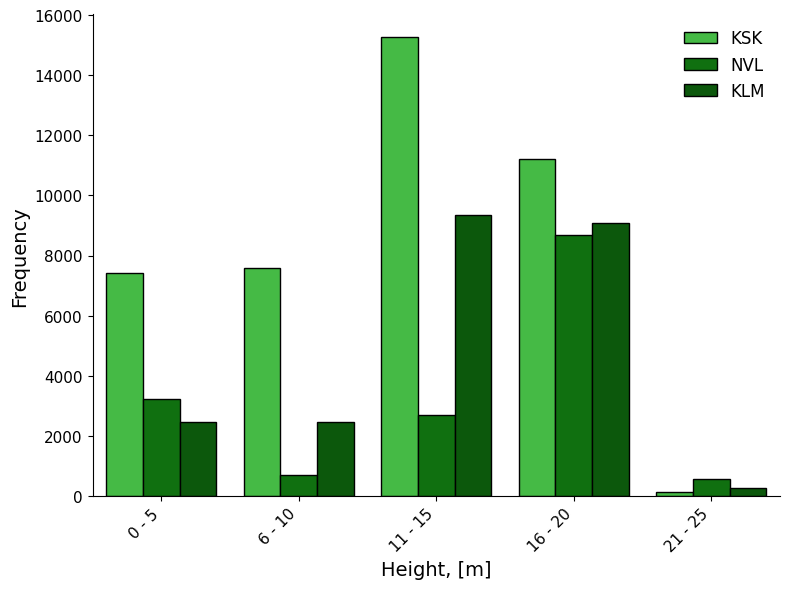

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. SET YOUR PATHS ---
NVL_GPKG = '/content/drive/MyDrive/Thesis/DataSet/NVL_Polygons.gpkg'
KSK_GPKG = '/content/drive/MyDrive/Thesis/DataSet/KSK_Polygons.gpkg'
KLM_GPKG = '/content/drive/MyDrive/Thesis/DataSet/KLM_Polygons.gpkg'

# --- 2. LOAD DATA DIRECTLY FROM GPKGs ---
print("Loading GeoPackages...")

# Load NVL and add a tag column
gdf_nvl = gpd.read_file(NVL_GPKG)
gdf_nvl['Forest'] = 'NVL'

# Load KSK and add a tag column
gdf_ksk = gpd.read_file(KSK_GPKG)
gdf_ksk['Forest'] = 'KSK'

# Load KLM and add a tag column
gdf_klm = gpd.read_file(KLM_GPKG)
gdf_klm['Forest'] = 'KLM'

# Combine all three into a single DataFrame for plotting
# (We drop the geometry column here because plotting a bar chart doesn't need spatial data, saving memory)
df = pd.concat([
    pd.DataFrame(gdf_nvl.drop(columns='geometry')),
    pd.DataFrame(gdf_ksk.drop(columns='geometry')),
    pd.DataFrame(gdf_klm.drop(columns='geometry'))
], ignore_index=True)

# --- (OPTIONAL) APPLY YOUR CLEANING FILTER ---
# df = df[~((df['age'] == 5) & (df['height'] > 10.0))]

# --- 3. BIN THE HEIGHT DATA ---
bins = [-0.1, 5, 10, 15, 20, 25]
labels = ['0 - 5', '6 - 10', '11 - 15', '16 - 20', '21 - 25']

df['Height_Class'] = pd.cut(df['height'], bins=bins, labels=labels)

# --- 4. CREATE THE PLOT ---
plt.figure(figsize=(8, 6))

# Specific colors mapped to your forests
forest_palette = {'KSK': 'limegreen', 'NVL': 'green', 'KLM': 'darkgreen'}

ax = sns.countplot(
    data=df,
    x='Height_Class',
    hue='Forest',
    palette=forest_palette,
    edgecolor='black', # Black outline
    linewidth=1,
    hue_order=['KSK', 'NVL', 'KLM']
)

# --- 5. AESTHETICS & LABELS ---
plt.xlabel('Height, [m]', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Clean legend and borders
plt.legend(title=None, frameon=False, fontsize=12)
sns.despine()

plt.tight_layout()

# Save and Show
output_plot = '/content/drive/MyDrive/Thesis/Height_Distribution_Plot.png'
plt.savefig(output_plot, dpi=300)
print(f"Plot saved successfully to {output_plot}")

plt.show()

Plot saved successfully to /content/drive/MyDrive/Thesis/Age_Class_Pie_Chart.png


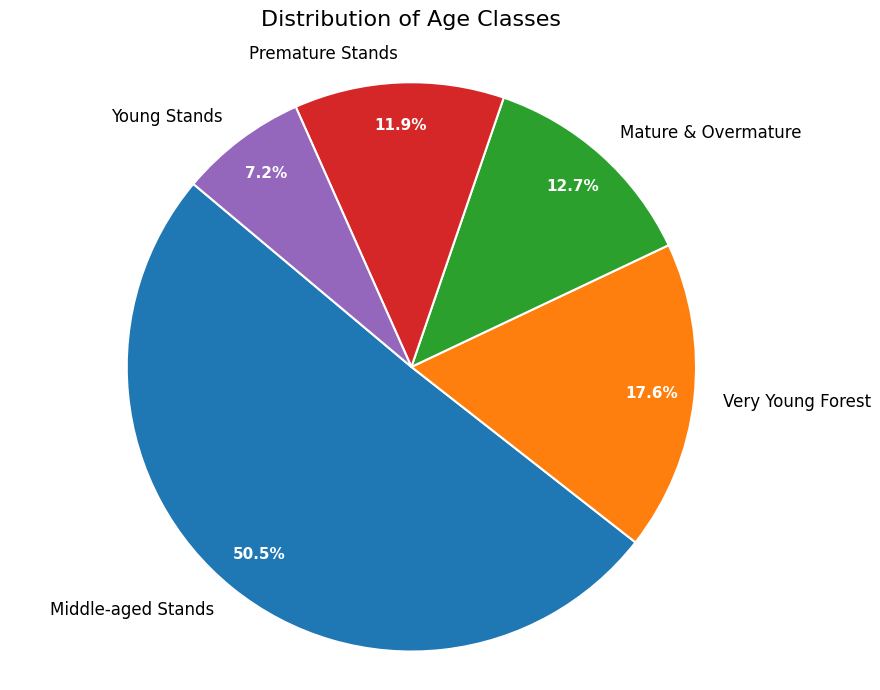

In [ ]:
import matplotlib.pyplot as plt


age_class_mapping = {
    1: 'Young Stands',
    2: 'Middle-aged Stands',
    3: 'Premature Stands',
    4: 'Mature & Overmature',
    5: 'Very Young Forest'
}
df['age_name'] = df['age'].map(age_class_mapping)
# 1. Count the occurrences of each age class in your dataframe
# (Assuming your column is named 'age_name'. If it's just 'age', swap it in!)
age_counts = df['age_name'].value_counts()

# 2. Set up the figure size
plt.figure(figsize=(9, 7))

# 3. Create the pie chart
# autopct='%1.1f%%' automatically calculates and displays the percentages
# pctdistance=0.8 pushes the percentage text outward for a cleaner look
wedges, texts, autotexts = plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%',
    startangle=140,              # Rotates the chart so it doesn't start at a harsh 0 degrees
    pctdistance=0.85,            # Distance of percentage text from center
    labeldistance=1.1,           # Distance of category labels from center
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5} # Adds clean white lines between slices
)

# 4. Make the text easy to read
plt.setp(texts, size=12)         # Category label font size
plt.setp(autotexts, size=11, weight="bold", color="white") # Percentage text styling

# If the white percentage text is hard to read on light colors, change color="white" to color="black"

# 5. Add a title
plt.title('Distribution of Age Classes', fontsize=16, pad=20)

# Ensure it's perfectly circular
plt.axis('equal')

plt.tight_layout()

# Save the plot
output_plot = '/content/drive/MyDrive/Thesis/Age_Class_Pie_Chart.png'
plt.savefig(output_plot, dpi=300)
print(f"Plot saved successfully to {output_plot}")

plt.show()